# CNN on CIFAR-10 with Feature Map Visualization

The **CIFAR-10 dataset** is a popular benchmark dataset for image classification tasks. It contains **60,000 color images** of size **32×32 pixels**, divided into **10 classes** such as airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. The dataset is split into **50,000 training images** and **10,000 test images**, with each class containing an equal number of samples, making it balanced. CIFAR-10 is widely used for evaluating **Convolutional Neural Networks (CNNs)** and other image recognition algorithms due to its moderate complexity, small size, and diverse color images.



This notebook demonstrates multiple CNN experiments to understand feature extraction and training on CIFAR-10.

**Experiments included:**
1. CIFAR-10 color dataset
2. Single-layer CNN with ReLU
3. Two-layer CNN with ReLU
4. Single-layer CNN with Tanh activation
5. Training and test accuracy tracking
6. Feature map visualization at 3 training stages


## 1. Import Libraries

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


## 2. Load CIFAR-10 Color Dataset

In [ ]:
#shift from (0,1) to (-1,1). Zero centering helps faster convergence.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

classes = train_dataset.classes


100%|██████████| 170M/170M [00:02<00:00, 79.4MB/s]


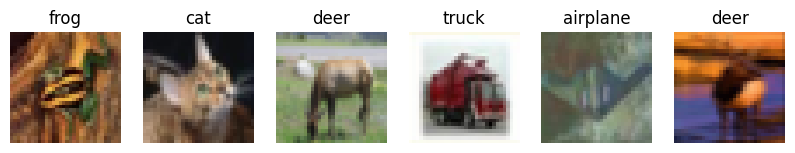

In [ ]:
# Visualize samples
examples = enumerate(train_loader) #assign index to samples
batch_idx, (example_data, example_targets) = next(examples) #first batch
plt.figure(figsize=(10,2))
for i in range(6): #print first 6 pics of first batch
    plt.subplot(1,6,i+1)
    img = example_data[i]/2 + 0.5 # shift from (0,1) to (-1,1)
    npimg = img.numpy() #tensor to numpy
    plt.imshow(np.transpose(npimg, (1,2,0)))
    '''CIFAR images are in format:
      (C, H, W) = (channels, height, width)
      But matplotlib expects:
      (H, W, C)
      So we transpose:
      (1,2,0)
    '''
    plt.title(classes[example_targets[i]])
    plt.axis('off')
plt.show()

## 3. Single-layer CNN (ReLU)

In [ ]:

class CNN1(nn.Module):
    def __init__(self):
        super(CNN1, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, 3) # 3 Channels (RGB), 8 Filters or Feature Maps, 3x3 Kernel
        self.pool = nn.MaxPool2d(2,2) #window 2*2, stride 2
        self.fc1 = nn.Linear(8*15*15, 10) #convulation process output 8*15*15, 10 classes
    def forward(self, x):
        x = F.relu(self.conv1(x))#conv1 extracts features, ReLU adds non-linearity:
        x = self.pool(x) #reduces spatial size
        x = x.view(-1, 8*15*15)#Converts 3D tensor → 1D vector per image
        x = self.fc1(x)
        return x


## 4. Two-layer CNN (ReLU)

In [ ]:
#Input → Conv1 → Conv2 → Pool → Flatten → FC → Output

class CNN2(nn.Module):
    def __init__(self):
        super(CNN2, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, 3) #input 3*32*32, output 8 × 30 × 30
        self.conv2 = nn.Conv2d(8, 16, 3) #input 8*30*30, output 16 × 28 × 28
        self.pool = nn.MaxPool2d(2,2) #16 × 28 × 28 becomes 16 × 14 × 14
        # Calculate the size of the flattened output after two conv layers and one pooling layer
        # Input size: 32x32
        # After conv1 (3x3 kernel, padding 0): (32-3+1) = 30x30
        # After conv2 (3x3 kernel, padding 0): (30-3+1) = 28x28
        # After pooling (2x2 kernel, stride 2): 28/2 = 14x14
        # Number of channels after conv2 is 16
        self.fc1 = nn.Linear(16*14*14, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*14*14) #convert to 1D 3136-dimensional vector
        x = self.fc1(x) #input 3136 features, output 10
        return x

## 5. Single-layer CNN (Tanh)

In [ ]:
#all same, just tanh instead of relu
class CNN1_Tanh(nn.Module):
    def __init__(self):
        super(CNN1_Tanh, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(8*15*15, 10)
    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)
        x = x.view(-1, 8*15*15)
        x = self.fc1(x)
        return x


## 6. Feature Map Helper Functions

In [ ]:
#Return feature maps from all Conv layers

def get_feature_maps(model, image):
    model.eval() #disables dropout, disables batchnorm updates

    outputs = [] #This list will store feature maps from each conv layer
    def hook_fn(module, input, output): #This function saves the output
        outputs.append(output)
    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, nn.Conv2d):
            hooks.append(layer.register_forward_hook(hook_fn))
            '''Loop through all layers in model
              Find only Conv2D layers
              Attach hook to each one
'''
    with torch.no_grad(): #no training
        _ = model(image.unsqueeze(0))
        ''''
        A single CIFAR-10 image is:

          (3, 32, 32)

          Meaning:

          3 → RGB channels
          32 × 32 → height and width

          2. What the model expects

          PyTorch CNN layers expect input like:

          (batch_size, channels, height, width)

          So even for one image, it must be:

          (1, 3, 32, 32)'''
    for h in hooks: #hooks are temp tools, so when work done, free memory
        h.remove()
    return outputs


## 7. Training Function

In [ ]:
def train_and_compare_feature_maps(model, train_loader, test_loader, sample_img, epochs=6, lr=0.001):
    # Set device to GPU if available, else CPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #Moves model to GPU if available for faster training.
    model.to(device)  # Move model to selected device

    # Define optimizer (Adam) and loss function (CrossEntropy for classification)
    optimizer = optim.Adam(model.parameters(), lr=lr)#Adam optimizer → updates weights efficiently, crossEntropyLoss → standard for classification
    criterion = nn.CrossEntropyLoss()

    # Lists to store training and validation accuracy for each epoch
    train_acc_list, val_acc_list = [], [] #training accuracy per epoch, test accuracy per epoch


    # List to store feature maps at different training stages
    feature_maps_stages = [] #feature maps at different training stages

    # Extract feature maps before training (initial weights)
    print('Feature maps: Initial weights')
    feature_maps_stages.append(get_feature_maps(model, sample_img)) #What does an untrained CNN see? Usually:random patterns, noisy filters"

    # Start training loop
    for epoch in range(epochs):
        model.train()  # Set model to training mode, readymade pytorch function
        correct, total = 0, 0  # Counters for training accuracy, total is number of images traversed

        # Iterate over batches in training data
        for data, target in train_loader:#loop through each batch
            data, target = data.to(device), target.to(device)  # Move batch to device

            optimizer.zero_grad()          # Clear previous gradients
            outputs = model(data)          # Forward pass
            loss = criterion(outputs, target)  # Compute loss
            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights

            # Compute training accuracy for this batch
            _, predicted = torch.max(outputs.data, 1) #picks highest score class
            total += target.size(0) #It keeps counting how many images seen so far
            correct += (predicted == target).sum().item() #counts correct predictions


        train_acc = correct / total  # Epoch training accuracy
        train_acc_list.append(train_acc)

        # Validation / Test Accuracy
        model.eval()  # Set model to evaluation mode
        correct, total = 0, 0
        with torch.no_grad():  # Disable gradient computation
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        val_acc = correct / total  # Epoch validation accuracy
        val_acc_list.append(val_acc)

        # Print epoch results
        print(f'Epoch {epoch+1}/{epochs}, Train Acc: {train_acc:.4f}, Test Acc: {val_acc:.4f}')

        # Save feature maps at half-training for analysis
        if epoch == epochs//2 - 1:
            print(f'Feature maps: After {epoch+1} epochs (half training)')
            feature_maps_stages.append(get_feature_maps(model, sample_img))

    # Extract feature maps after full training
    print('Feature maps: After full training')
    feature_maps_stages.append(get_feature_maps(model, sample_img))

    # Plot training and validation accuracy over epochs
    plt.figure(figsize=(8,4))
    plt.plot(range(1, epochs+1), train_acc_list, label='Train')
    plt.plot(range(1, epochs+1), val_acc_list, label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training & Test Accuracy')
    plt.legend()
    plt.show()

    # Return trained model and feature maps at different stages
    return model, feature_maps_stages

## 8. Experiments

**8.1 Single Layer CNN (ReLu)**

In [ ]:
print("### 8.1 Single-layer CNN (ReLU) Experiment ###")

# Take a sample image from train_loader for feature visualization
sample_img, _ = next(iter(train_loader)) #DataLoader → gives batches of data, gets first batch
sample_img = sample_img[0]  # Take the first image

cnn1 = CNN1()
cnn1_trained, cnn1_feature_maps = train_and_compare_feature_maps(
    cnn1, train_loader, test_loader, sample_img, epochs=6, lr=0.001
)

### 8.1 Single-layer CNN (ReLU) Experiment ###
Feature maps: Initial weights
Epoch 1/6, Train Acc: 0.4461, Test Acc: 0.4987
Epoch 2/6, Train Acc: 0.5294, Test Acc: 0.5342
Epoch 3/6, Train Acc: 0.5564, Test Acc: 0.5408
Feature maps: After 3 epochs (half training)
Epoch 4/6, Train Acc: 0.5691, Test Acc: 0.5576
Epoch 5/6, Train Acc: 0.5813, Test Acc: 0.5608


In [ ]:
# Visualize feature maps at 3 stages
stages = ['Initial', 'Half-training', 'Full-training']
for stage, fmap in zip(stages, cnn1_feature_maps):
    plt.figure(figsize=(12,4))
    for i in range(min(8, fmap[0].shape[1])):  # show up to 8 filters
        plt.subplot(1,8,i+1)
        plt.imshow(fmap[0][0,i].cpu().numpy(), cmap='gray')
        plt.axis('off')
        plt.title(f'F{i+1}')
    plt.suptitle(f'Single-layer CNN (ReLU) - {stage} Feature Maps')
    plt.show()

**8.2 Two Layer CNN**

In [ ]:
print("### 8.2 Two-layer CNN (ReLU) Experiment ###")

cnn2 = CNN2()
cnn2_trained, cnn2_feature_maps = train_and_compare_feature_maps(
    cnn2, train_loader, test_loader, sample_img, epochs=6, lr=0.001
)

In [ ]:
# Visualize feature maps after first conv layer
for stage, fmap in zip(stages, cnn2_feature_maps):
    plt.figure(figsize=(12,4))
    for i in range(min(8, fmap[0].shape[1])):  # first conv layer filters
        plt.subplot(1,8,i+1)
        plt.imshow(fmap[0][0,i].cpu().numpy(), cmap='gray')
        plt.axis('off')
        plt.title(f'F{i+1}')
    plt.suptitle(f'Two-layer CNN (ReLU) - {stage} First Conv Feature Maps')
    plt.show()

In [ ]:
# Visualize feature maps after first conv layer
for stage, fmap in zip(stages, cnn2_feature_maps):
    plt.figure(figsize=(12,4))
    for i in range(min(16, fmap[1].shape[1])):  # second conv layer filters
        plt.subplot(1,16,i+1)
        plt.imshow(fmap[1][0,i].cpu().numpy(), cmap='gray')
        plt.axis('off')
        plt.title(f'F{i+1}')
    plt.suptitle(f'Two-layer CNN (ReLU) - {stage} Second Conv Feature Maps')
    plt.show()

**8.3 Single Layer CNN (Tanh)**

In [ ]:
print("### 8.3 Single-layer CNN (Tanh) Experiment ###")

cnn1_tanh = CNN1_Tanh()
cnn1_tanh_trained, cnn1_tanh_feature_maps = train_and_compare_feature_maps(
    cnn1_tanh, train_loader, test_loader, sample_img, epochs=6, lr=0.001
)

In [ ]:
# Visualize feature maps at 3 stages
for stage, fmap in zip(stages, cnn1_tanh_feature_maps):
    plt.figure(figsize=(12,4))
    for i in range(min(8, fmap[0].shape[1])):  # show up to 8 filters
        plt.subplot(1,8,i+1)
        plt.imshow(fmap[0][0,i].cpu().numpy(), cmap='gray')
        plt.axis('off')
        plt.title(f'F{i+1}')
    plt.suptitle(f'Single-layer CNN (Tanh) - {stage} Feature Maps')
    plt.show()

## 9. Comparison & Insights

In [ ]:
# Collect final test accuracies
cnn1_final_acc = train_and_compare_feature_maps(cnn1, train_loader, test_loader, sample_img, epochs=0)[1][-1]
cnn2_final_acc = train_and_compare_feature_maps(cnn2, train_loader, test_loader, sample_img, epochs=0)[1][-1]
cnn1_tanh_final_acc = train_and_compare_feature_maps(cnn1_tanh, train_loader, test_loader, sample_img, epochs=0)[1][-1]


In [ ]:
print("### Final Test Accuracies ###")
print(f"Single-layer CNN (ReLU): {cnn1_final_acc:.4f}")
print(f"Two-layer CNN (ReLU): {cnn2_final_acc:.4f}")
print(f"Single-layer CNN (Tanh): {cnn1_tanh_final_acc:.4f}\n")